In [1]:
import torch
import torchvision
import matplotlib.pyplot as plt

print("PyTorch Version:", torch.__version__)
print("Torchvision Version:", torchvision.__version__)
print("CUDA Available:", torch.cuda.is_available())

PyTorch Version: 2.14.0+cpu
Torchvision Version: 0.29.0+cpu
CUDA Available: False


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

print("PyTorch Version:", torch.__version__)
print("Device:", "CUDA" if torch.cuda.is_available() else "CPU")

PyTorch Version: 2.14.0+cpu
Device: CPU


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

trainset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

testset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

trainloader = DataLoader(trainset, batch_size=128, shuffle=True)

testloader = DataLoader(testset, batch_size=128, shuffle=False)

print("Training Images:", len(trainset))
print("Testing Images :", len(testset))

Training Images: 50000
Testing Images : 10000


In [4]:
class MLP(nn.Module):

    def __init__(self):
        super().__init__()

        self.flatten = nn.Flatten()

        self.network = nn.Sequential(

            nn.Linear(3*32*32,256),

            nn.ReLU(),

            nn.Linear(256,128),

            nn.ReLU(),

            nn.Linear(128,10)

        )

    def forward(self,x):

        x=self.flatten(x)

        return self.network(x)

In [5]:
def train(model, optimizer, epochs=10):

    model.to(device)

    criterion = nn.CrossEntropyLoss()

    losses = []

    accuracies = []

    for epoch in range(epochs):

        model.train()

        running_loss = 0

        correct = 0

        total = 0

        for images, labels in trainloader:

            images = images.to(device)

            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            optimizer.zero_grad()

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

            _, predicted = torch.max(outputs,1)

            total += labels.size(0)

            correct += (predicted==labels).sum().item()

        epoch_loss = running_loss / len(trainloader)

        epoch_acc = 100 * correct / total

        losses.append(epoch_loss)

        accuracies.append(epoch_acc)

        print(f"Epoch {epoch+1}/{epochs}  Loss:{epoch_loss:.4f}  Accuracy:{epoch_acc:.2f}%")

    return losses, accuracies

In [6]:
def test(model):

    model.eval()

    correct = 0

    total = 0

    with torch.no_grad():

        for images, labels in testloader:

            images = images.to(device)

            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs,1)

            total += labels.size(0)

            correct += (predicted==labels).sum().item()

    accuracy = 100*correct/total

    return accuracy

In [7]:
model_sgd = MLP()

optimizer_sgd = optim.SGD(
    model_sgd.parameters(),
    lr=0.01,
    momentum=0.9
)

loss_sgd, acc_sgd = train(model_sgd, optimizer_sgd, epochs=10)

test_acc_sgd = test(model_sgd)

print("\nSGD Test Accuracy =", round(test_acc_sgd,2),"%")

Epoch 1/10  Loss:1.7854  Accuracy:36.57%
Epoch 2/10  Loss:1.5086  Accuracy:46.80%
Epoch 3/10  Loss:1.3897  Accuracy:51.14%
Epoch 4/10  Loss:1.3121  Accuracy:54.02%
Epoch 5/10  Loss:1.2419  Accuracy:56.36%
Epoch 6/10  Loss:1.1838  Accuracy:58.36%
Epoch 7/10  Loss:1.1297  Accuracy:60.44%
Epoch 8/10  Loss:1.0796  Accuracy:62.22%
Epoch 9/10  Loss:1.0292  Accuracy:63.85%
Epoch 10/10  Loss:0.9840  Accuracy:65.29%

SGD Test Accuracy = 54.33 %


In [8]:
model_adam = MLP()

optimizer_adam = optim.Adam(
    model_adam.parameters(),
    lr=0.001
)

loss_adam, acc_adam = train(model_adam, optimizer_adam, epochs=10)

test_acc_adam = test(model_adam)

print("\nAdam Test Accuracy =", round(test_acc_adam,2),"%")

Epoch 1/10  Loss:1.6399  Accuracy:41.96%
Epoch 2/10  Loss:1.4186  Accuracy:50.05%
Epoch 3/10  Loss:1.3109  Accuracy:54.01%
Epoch 4/10  Loss:1.2283  Accuracy:56.63%
Epoch 5/10  Loss:1.1529  Accuracy:59.32%
Epoch 6/10  Loss:1.0887  Accuracy:61.57%
Epoch 7/10  Loss:1.0261  Accuracy:63.77%
Epoch 8/10  Loss:0.9696  Accuracy:65.56%
Epoch 9/10  Loss:0.9049  Accuracy:68.14%
Epoch 10/10  Loss:0.8608  Accuracy:69.55%

Adam Test Accuracy = 54.19 %


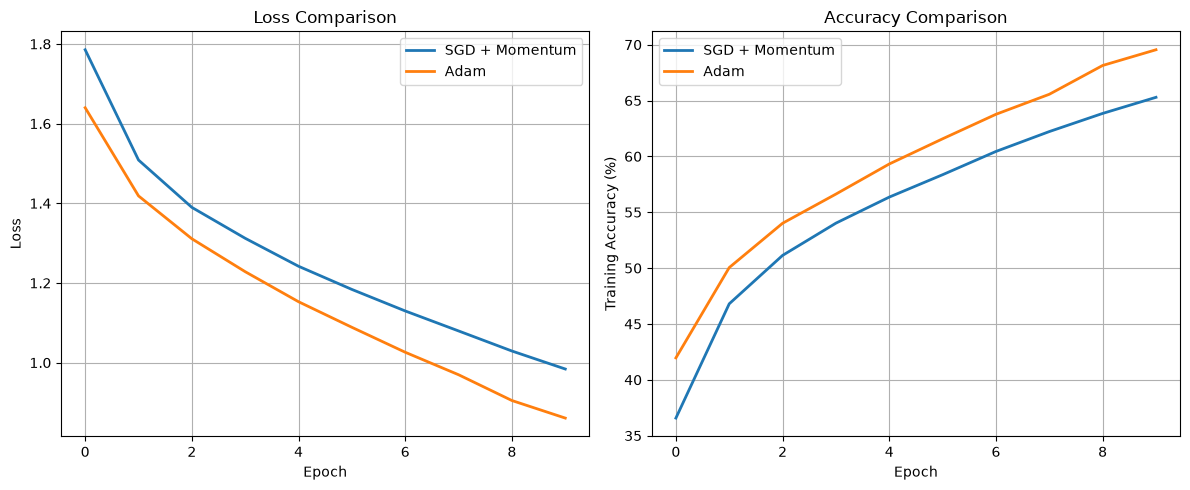

In [9]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(loss_sgd,label="SGD + Momentum",linewidth=2)

plt.plot(loss_adam,label="Adam",linewidth=2)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Loss Comparison")

plt.legend()

plt.grid()

plt.subplot(1,2,2)

plt.plot(acc_sgd,label="SGD + Momentum",linewidth=2)

plt.plot(acc_adam,label="Adam",linewidth=2)

plt.xlabel("Epoch")

plt.ylabel("Training Accuracy (%)")

plt.title("Accuracy Comparison")

plt.legend()

plt.grid()

plt.tight_layout()

plt.show()